In [ ]:
from datasets import load_dataset

dataset = load_dataset("google/speech_commands", "v0.01")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 51093
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 6799
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 3081
    })
})
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
Label names: ['yes', 'no

In [37]:
print(dataset.keys())
print(dataset["validation"].features)
print(dataset["validation"][0])
print(f"Label names: {dataset['train'].features['label'].names}")

dict_keys(['train', 'validation', 'test'])
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
{'file': 'eight/2ce7534c_nohash_1.wav', 'audio': {'path': 'eight/2ce7534c_nohash_1.wav', 'array': array([-0.00076294, -0.00201416, -0.00204468, ..., -0.00439453,
       -0.00189209, -0.00115967], shape=(16000,)), 'sampling_rate': 16000}, 'label': 18, 'is_unknown': True, 'speaker_id': '2ce7534c', 'utterance_id': 1}
Label names: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'th

In [ ]:
label_names = dataset["train"].features["label"].names
digit_labels = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
digit_ids = [label_names.index(label) for label in digit_labels]

def is_digit(example):
    return example["label"] in digit_ids

dataset = dataset.filter(is_digit)
print(dataset)


Filter:   0%|          | 0/18620 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2494 [00:00<?, ? examples/s]

Filter:   0%|          | 0/160 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 18620
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 2494
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 160
    })
})
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}


In [ ]:
label_names = dataset["train"].features["label"].names
present = set(dataset["train"]["label"])
print([label_names[i] for i in present])

['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']


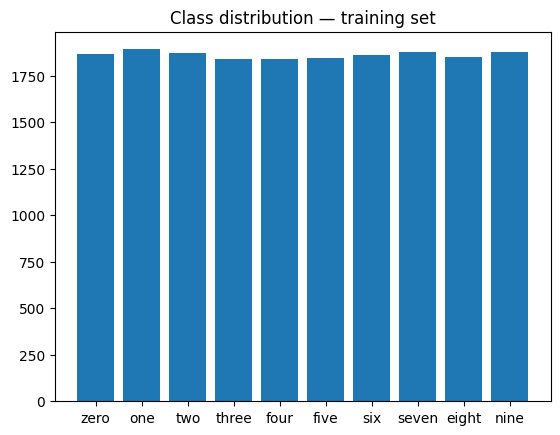

In [ ]:
import collections, matplotlib.pyplot as plt
counts = collections.Counter(dataset["train"]["label"])
plt.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)])
plt.title("Class distribution — training set")
plt.savefig("class_balance.png")

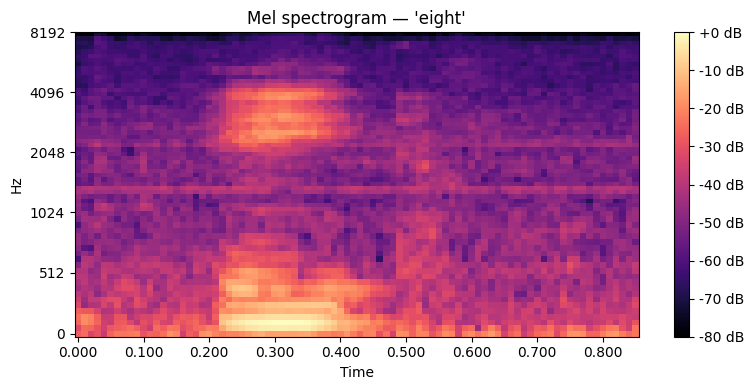

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def compute_mel(audio_array, sr=16000):
    mel = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=64, n_fft=400, hop_length=160)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

sample = dataset["train"][0]
audio = np.array(sample["audio"]["array"], dtype=np.float32)
label = dataset["train"].features["label"].names[sample["label"]]

mel = compute_mel(audio)

plt.figure(figsize=(8, 4))
librosa.display.specshow(mel, sr=16000, hop_length=160, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel spectrogram — '{label}'")
plt.tight_layout()
plt.show()